# Práctica 04: Análisis de Datos Exploratorio con Python y Jupyter Notebook en un Dataset de Productos de Amazon Store

**Programa de estudios:** Ingeniería en Entornos Vistuales Y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Período:** Mayo - Agosto 2026 

### Unidad 2: Preparación de los Datos

**Nombre del estudiante:** Karla Yulenni Domínguez Amador \
**Matrícula:** 230284 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%);
padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo
& Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías ·
Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

### 📋 Tabla de contenidos

---

| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de datos](#s1) | Librerías, carga de CSV, primeros comandos de estructura |
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular % de datos faltantes |
| 3 | [Limpieza de Datos](#s3) | Aplicación de los métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos) |
| 4 | [Ingeniería de características](#s4) | Variables de texto, banderas de categoría, categorías de precio |
| 5 | [Análisis univariado](#s5) | Distribuciones, valores atípicos, pruebas de normalidad |
| 6 | [Análisis por Categoría](#s6) | Top categorías, precio por categoría |
| 7 | [Análisis de Disponibilidad](#s7) | Patrones del estado de stock |
| 8 | [Correlación y Análisis Bivariado](#s8) | Heatmap, gráficos de dispersión |
| 9 | [Pruebas de Hipótesis Estadísticas](#s9) | ANOVA, Kruskal-Wallis, Spearman |
| 10 | [Planteamiento del Problema ML](#s10) | Matriz de características, división train/test |
| 11 | [Estructura para Selección de Modelos](#s11) | Tabla de comparación de modelos y métricas |
| 12 | [Modelos de Regresión](#s12) | Entrenamiento y evaluación de 5 modelos de regresión |
| 13 | [Optimización de Hiperparámetros](#s13) | Aplicación de GridSearchCV sobre el mejor modelo |
| 14 | [Comparación de Modelos](#s14) | Resultados lado a lado, importancia de las características |
| 15 | [Conclusiones Clave y Reporte](#s15) | Hallazgos del negocio, recomendaciones |

## 1. Instalaciones & Carga de Datos 🔧  <a id='s1'></a>

<div style="background: #f8f8ff; padding: 12px; border-left: 4px solid #FF9900;
border-radius: 5px; color: #0066cc;">

<b>Dataset:</b>  Amazon India Listas de Productos - 1,436 productos entre
Libros, Kindle, Deportes & Más

<b>Objetivo:</b>  Predecir el precio del producto (INR) desde la categoría,
longitud del nombre y disponibilidad

<b>DataSource:</b>  Web-scraped de páginas de productos Amazon.in

</div>

In [47]:
#========================================================================================
#SECTION 1 Setup & Data Loading
#========================================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from scipy import stats

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False


#ML Machine Learning -  Entrenamiento de modelos matemáticos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅Pandas : {pd.__version__}')
print(f'✅Pandas : {pd.__version__}')
print('Todas las librerias se cargaron con éxito!')

✅Pandas : 2.3.3
✅Pandas : 2.3.3
Todas las librerias se cargaron con éxito!


In [7]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape   : {df_raw.shape}')
print(f'📋 Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

📦 Shape   : (1444, 17)
📋 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame. <a id='s2'></a>

In [8]:
# Column dictionary
col_info = {
    'rl'                   : 'URL del Producto en Amazon.in',
    'asin'                 : 'Numero Estandarizado de Identificación por Amazon (unique ID)',
    'name'                 : 'Nombre o Título del Producto',
    'overview'             : 'Breve reseña del producto (mayoría vacío[])',
    'price'                : 'Precio como string (e.g. "1,600.00")',
    'currency'             : 'Código de Divisa (todas en INR)',
    'availability'         : 'Texto del Status del Stock (Inventario)',
    'brand'                : 'Nombre de la Marca/Autor',
    'about_item'           : 'Detalles/Especificaciones (mayoria faltante)',
    'img_source'           : 'URLs de Imagenes del Producto',
    'description'          : 'Descripción detallada y completa (mayoria faltante)',
    'specifications'       : 'Especificaciones Técnicas',
    'primary_category'     : 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'           : 'Subcategoría de nivel 1',
    'category_2'           : 'Subcategoría de nivel 2',
    'category_3'           : 'Subcategoría de nivel 3',
    'breadcrumbs'          : 'Ruta de Categorias'
}

print(' Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

 

 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Numero Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Producto                  | Missing: 0%
overview             | Breve reseña del producto (mayoría vacío[])   | Missing: 0%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoria faltante)  | Missing: 92%
img_source           | URLs de Imagenes del Producto                 | Missing: 0%
description          | Descripción detallada y completa (mayoria fal | Missing: 93%
specifications       | Especificaciones Técnicas       

## 3. Limpieza de Datos <a id='s3'></a>

<div style="background: #fff8e1;  padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
- Parsear el precio strings como "1,600.00" → float 1600.0<br>
- Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
- Estandarizar el texto de disponibilidad en categorías limpias<br>
- Eliminar duplicados
</div>

In [9]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,098 / 1,444 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 480, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


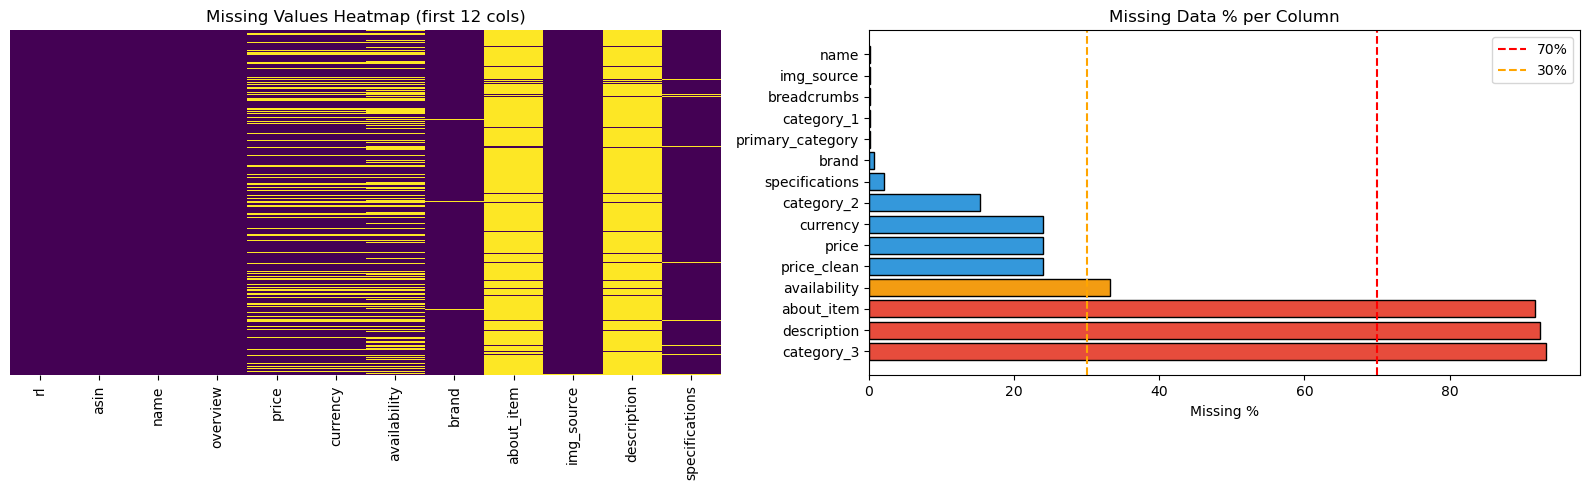

                  Missing Count  Missing Pct
category_3                 1347         93.3
description                1336         92.5
about_item                 1325         91.8
availability                480         33.2
price_clean                 346         24.0
price                       346         24.0
currency                    346         24.0
category_2                  221         15.3
specifications               30          2.1
brand                        10          0.7
primary_category              1          0.1
category_1                    1          0.1
breadcrumbs                   1          0.1
img_source                    1          0.1
name                          1          0.1


In [10]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

colors_mv = [
    '#e74c3c' if v > 70
    else '#f39c12' if v > 30
    else '#3498db'
    for v in mv['Missing Pct']
]

axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingeniería de caracteristicas (Feature Engineering) <a id='s4'></a>

<div style="background: #f0fff0;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrs brutos, sino que tambien considera la ubicación, la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos información más valios adel texto sin procesar y las categorías..

</div>

In [11]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total Características (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total Características (Atributos) Procesadas (Features Engineered): 39

Precio por cada tipo (tier) distribucion:
price_tier
1_budget     105
2_low        287
3_mid        319
4_premium    261
5_luxury     126
Unknown      346


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis univariado 📊 <a id='s5'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b>¿Cómo se ve la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?

</div>

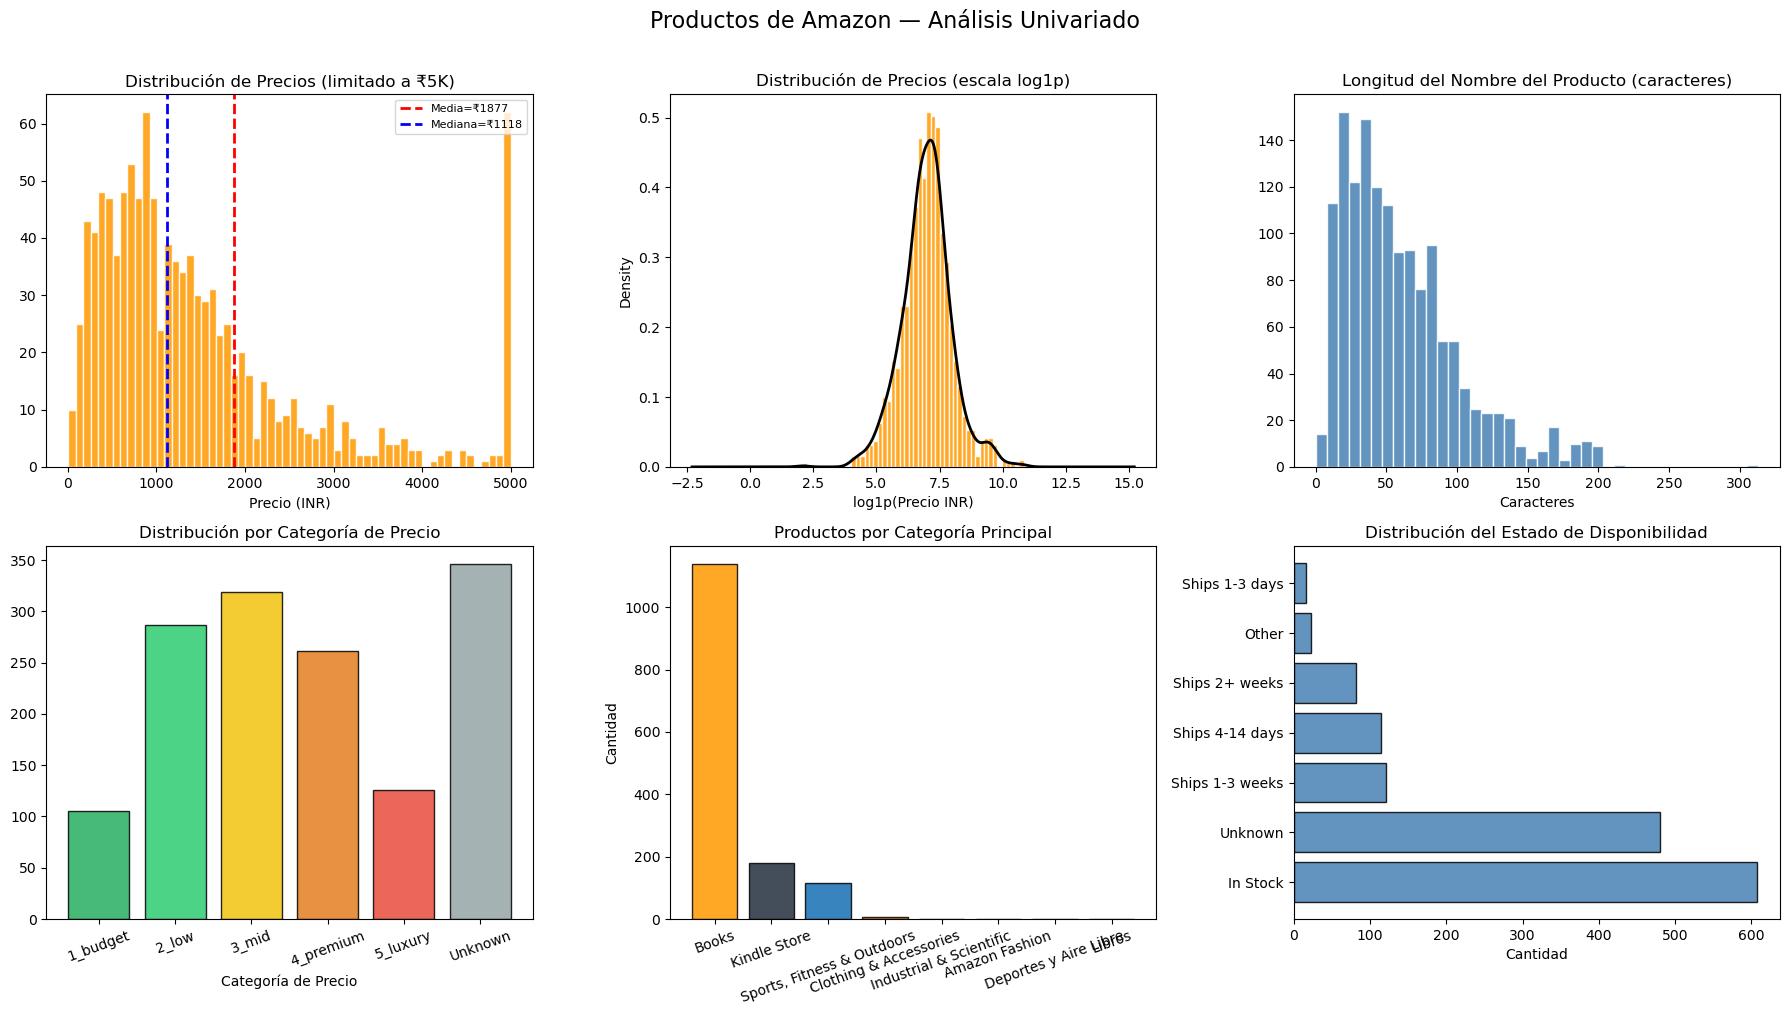

Shapiro-Wilk (precio log, n=500): estadístico=0.9805, p=0.000003
El precio sigue sin ser normal después de la transformación log

Estadísticas de precio (INR):
count     1091.00
mean      1876.93
std       3334.33
min          7.00
25%        609.94
50%       1118.00
75%       1849.50
max      50555.00


In [12]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Precio (crudo)
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de Precios (limitado a ₹5K)')
axes[0,0].set_xlabel('Precio (INR)'); axes[0,0].legend(fontsize=8)

# Precio (escala logarítmica)
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de Precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# Longitud del nombre
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del Nombre del Producto (caracteres)')
axes[0,2].set_xlabel('Caracteres')

# Categoría de precio (tier)
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por Categoría de Precio')
axes[1,0].set_xlabel('Categoría de Precio'); axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_ylabel('Cantidad'); axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle('Productos de Amazon — Análisis Univariado', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Prueba de normalidad
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (precio log, n=500): estadístico={stat:.4f}, p={p:.6f}')
print(f'El precio {"sigue una distribución normal después de la transformación log" if p > 0.05 else "sigue sin ser normal después de la transformación log"}')
print(f'\nEstadísticas de precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

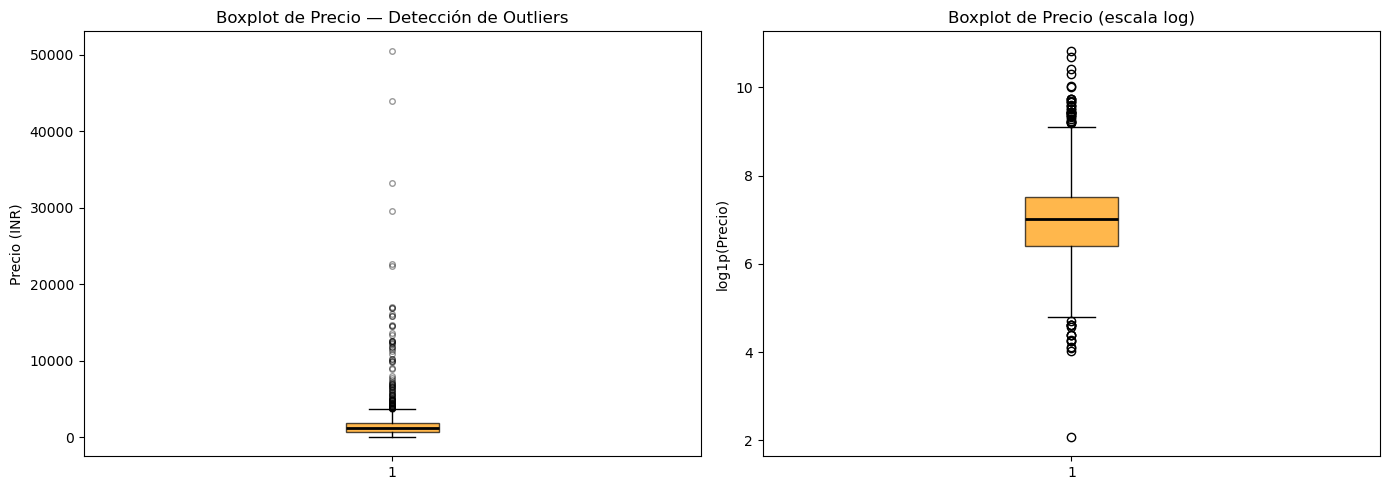

Outliers detectados por método IQR: 93 (8.5%)
Rango de precio (sin outliers): ₹-1249 – ₹3709

Top 10 productos más caros:
                                                                                                                                      nombre   precio        categoria_principal
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032 50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications 43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides) 33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series) 29633.00                     

In [13]:
# Análisis de valores atípicos (outliers) — boxplot e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Boxplot de Precio — Detección de Outliers')
axes[0].set_ylabel('Precio (INR)')
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Boxplot de Precio (escala log)')
axes[1].set_ylabel('log1p(Precio)')
plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'Outliers detectados por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precio (sin outliers): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

print(f'\nTop 10 productos más caros:')
top10_es = df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].copy()
top10_es.columns = ['nombre', 'precio', 'categoria_principal']
print(top10_es.to_string(index=False))

## 6. Análisis de Categorías 🗂️ <a id='s6'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b>¿Qué categorías tienen los precios más altos? ¿Qué subcategorías dominan? ¿Dónde está el mayor valor?

</div>

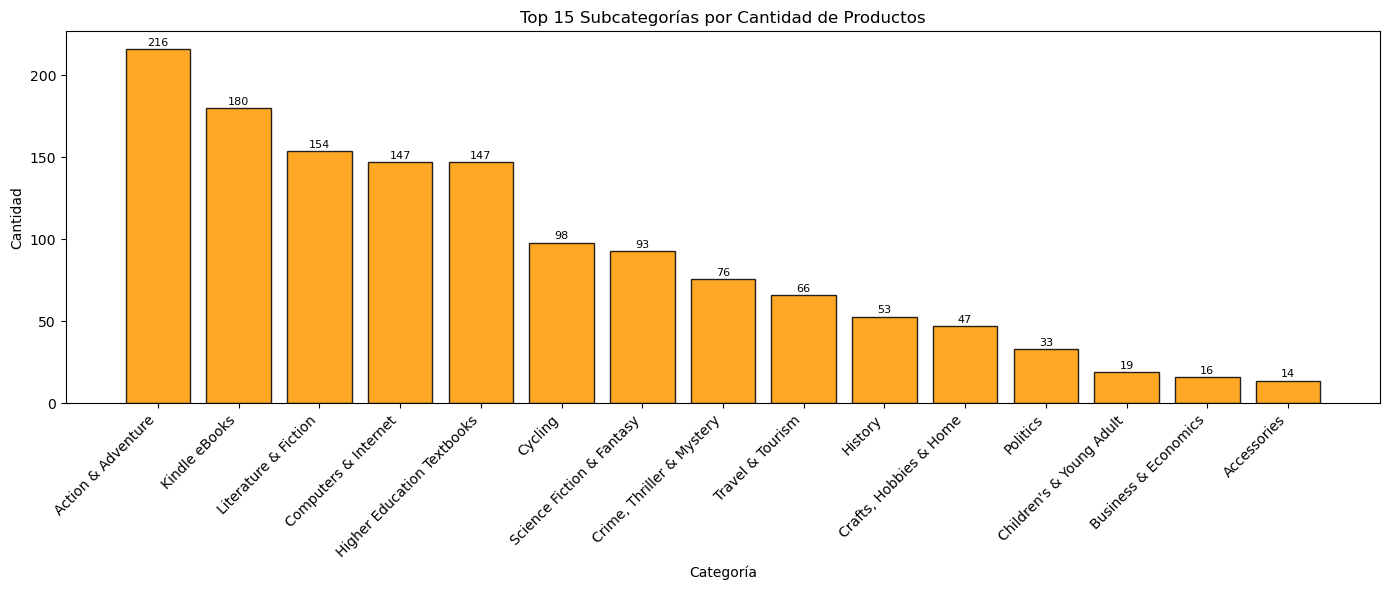

In [14]:
# ============================================================
# SECCIÓN 5 — Análisis por Categoría
# ============================================================
# Top 15 subcategorías por cantidad
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Categoría'); plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

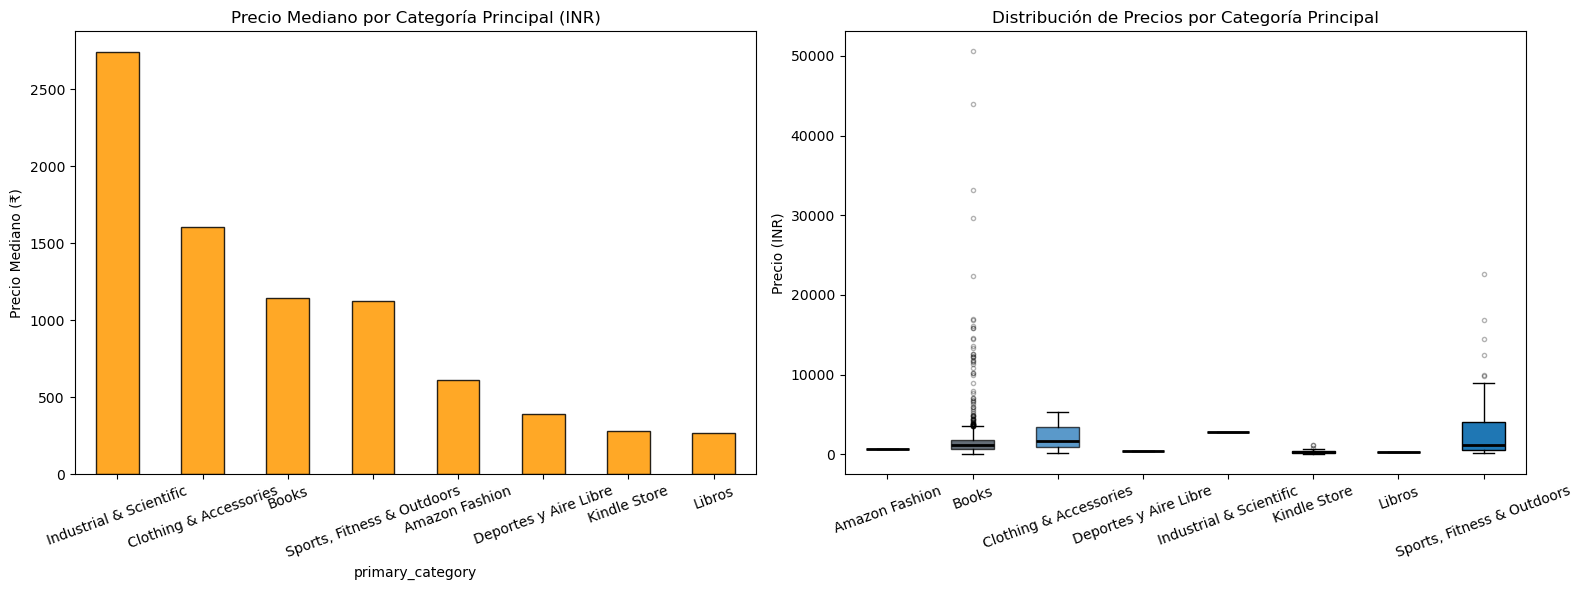

Estadísticas de precio por categoría principal:
                              mean  median  count
primary_category                                 
Amazon Fashion               610.9   610.9      1
Books                       1826.0  1145.0    957
Clothing & Accessories      2249.2  1606.5      6
Deportes y Aire Libre        392.3   392.3      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Libros                       268.0   268.0      1
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [15]:
# Precio por categoría principal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_ylabel('Precio Mediano (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, tick_labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Estadísticas de precio por categoría principal:')
print(cat_price.to_string())

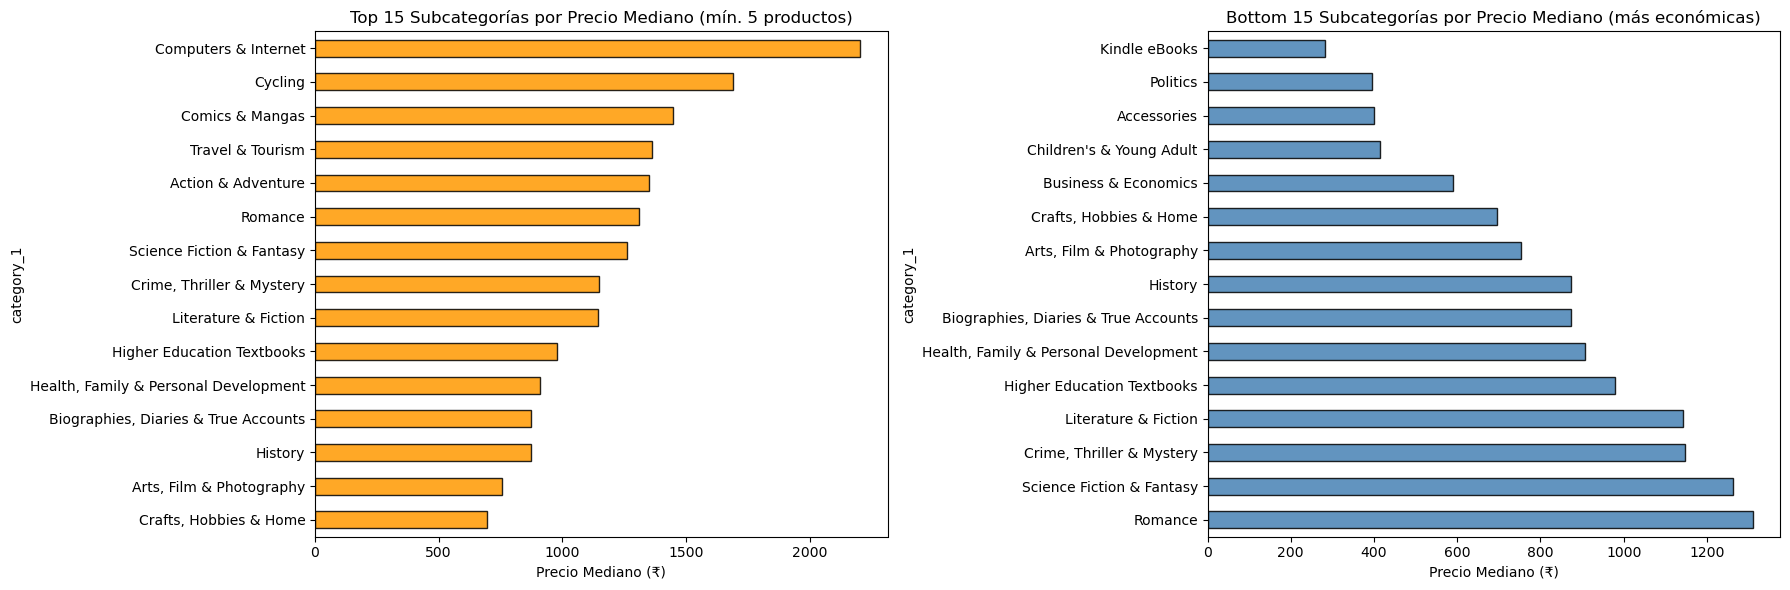

In [16]:
# Top 15 subcategorías por precio mediano
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Subcategorías por Precio Mediano (mín. 5 productos)')
axes[0].set_xlabel('Precio Mediano (₹)')

# Bottom 15 (más económicas)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Subcategorías por Precio Mediano (más económicas)')
axes[1].set_xlabel('Precio Mediano (₹)')

plt.tight_layout(); plt.show()

## 7. Análisis de disponibilidad <a id='s7'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b>¿El estado de disponibilidad afecta el precio? ¿Es más probable que los productos premium estén agotados?

</div>

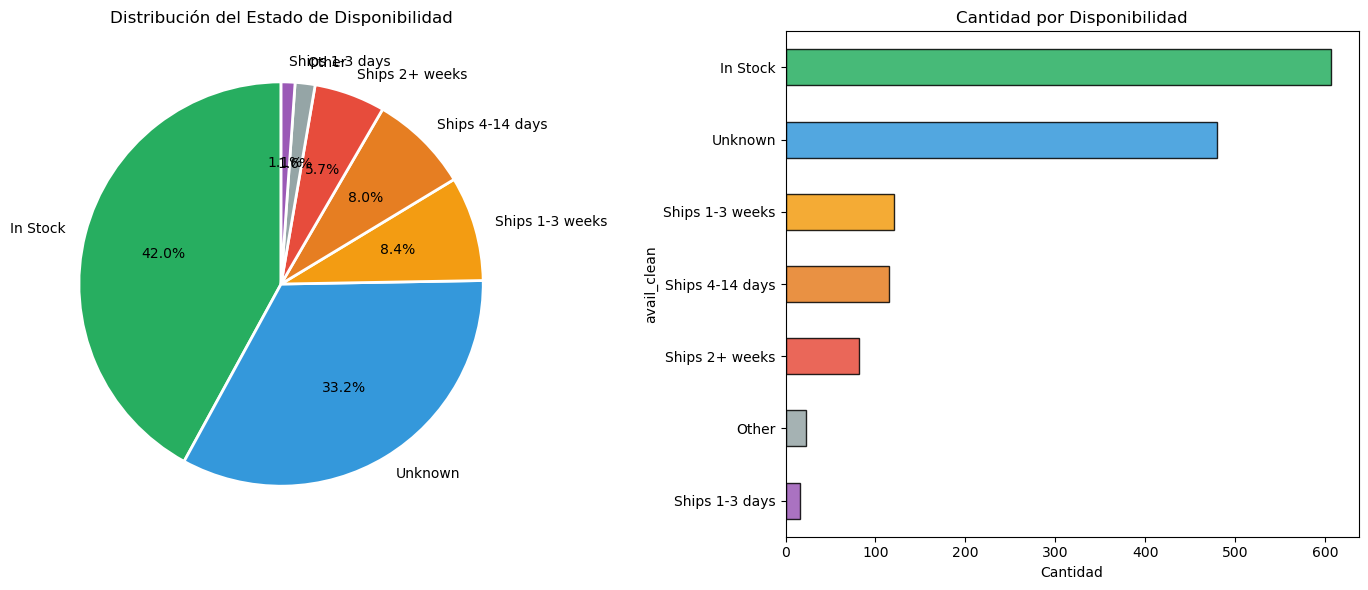

In [17]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del Estado de Disponibilidad')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad por Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout(); plt.show()

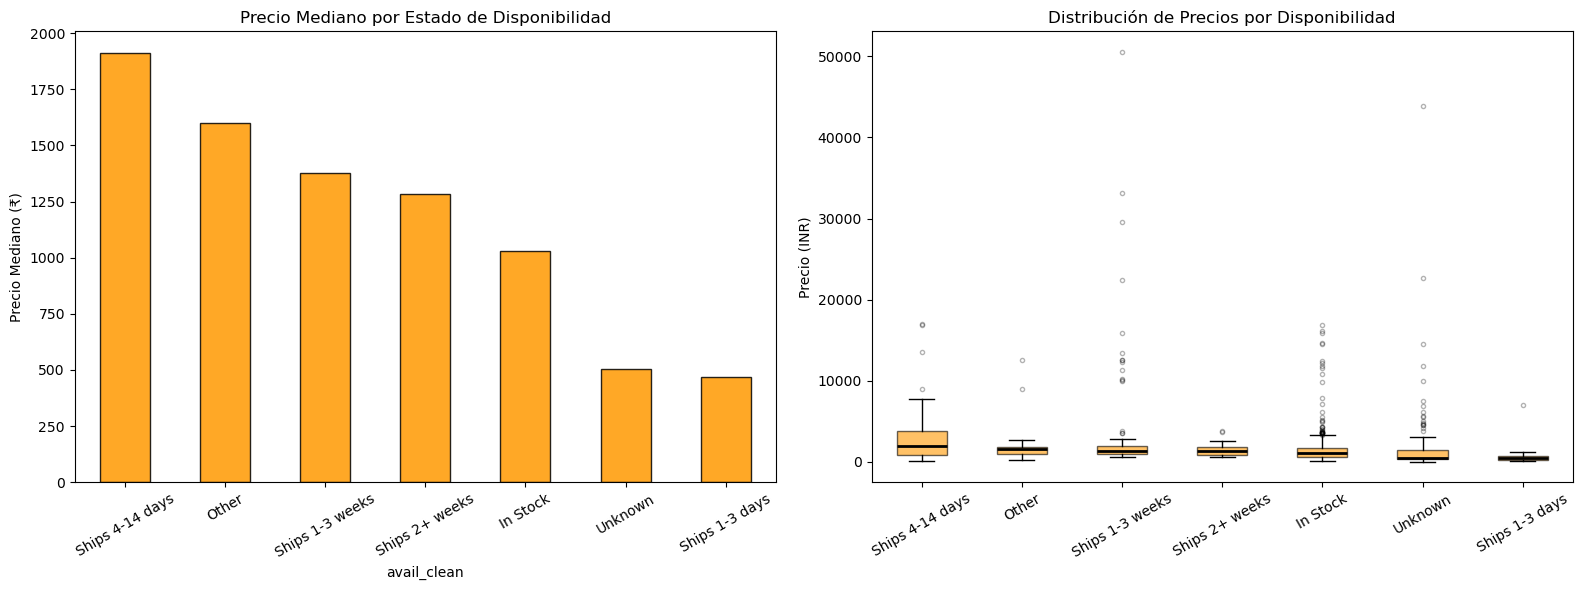

Precio por disponibilidad:
                      mediana   media  cantidad
disponibilidad                                 
Envía en 4-14 días     1912.3  2874.6       115
Otro                   1600.0  2193.9        23
Envía en 1-3 semanas   1377.0  3231.6       121
Envía en 2+ semanas    1284.5  1403.9        82
En stock               1030.0  1490.5       599
Desconocido             503.0  1879.4       135
Envía en 1-3 días       469.0   874.9        16


In [18]:
# Precio por estado de disponibilidad
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

# Traducción de los valores de disponibilidad y nombres de columnas para mostrar en español
avail_translation = {
    'Ships 4-14 days': 'Envía en 4-14 días',
    'Other': 'Otro',
    'Ships 1-3 weeks': 'Envía en 1-3 semanas',
    'Ships 2+ weeks': 'Envía en 2+ semanas',
    'In Stock': 'En stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 days': 'Envía en 1-3 días'
}
avail_price_es = avail_price.rename(index=avail_translation)
avail_price_es = avail_price_es.rename(columns={'median': 'mediana', 'mean': 'media', 'count': 'cantidad'})
avail_price_es.index.name = 'disponibilidad'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Precio Mediano por Estado de Disponibilidad')
axes[0].set_ylabel('Precio Mediano (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, tick_labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

print('Precio por disponibilidad:')
print(avail_price_es.to_string())

## 8. Correlación y Análisis Bivariado 🔗 <a id='s8'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b>¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?

</div>

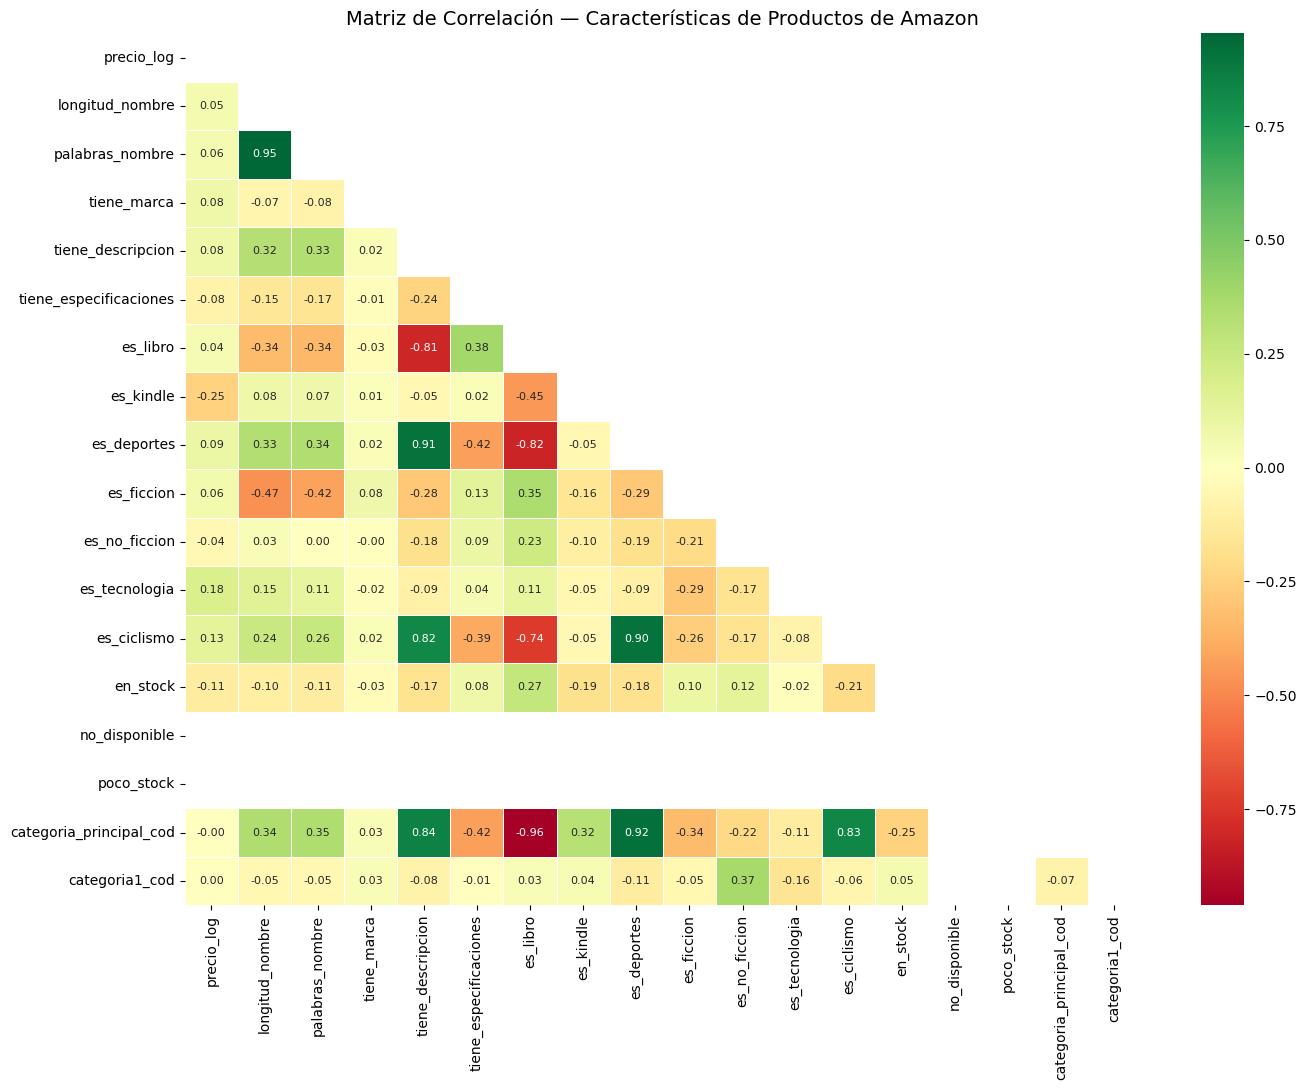

Principales correlaciones con precio_log:
es_tecnologia              0.177478
es_ciclismo                0.127095
es_deportes                0.092323
tiene_marca                0.083459
tiene_descripcion          0.081337
es_ficcion                 0.056214
palabras_nombre            0.055558
longitud_nombre            0.050149
es_libro                   0.043516
categoria1_cod             0.001138
categoria_principal_cod   -0.003571
es_no_ficcion             -0.042961
tiene_especificaciones    -0.076074
en_stock                  -0.110955
es_kindle                 -0.245832
no_disponible                   NaN
poco_stock                      NaN


In [19]:
# ============================================================
# SECCIÓN 7 — Análisis de Correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Traducción de los nombres de variables para mostrar en la gráfica y en el resultado impreso
nombres_es = {
    'log_price': 'precio_log',
    'name_length': 'longitud_nombre',
    'name_words': 'palabras_nombre',
    'has_brand': 'tiene_marca',
    'has_desc': 'tiene_descripcion',
    'has_specs': 'tiene_especificaciones',
    'is_book': 'es_libro',
    'is_kindle': 'es_kindle',
    'is_sports': 'es_deportes',
    'is_fiction': 'es_ficcion',
    'is_nonfiction': 'es_no_ficcion',
    'is_tech': 'es_tecnologia',
    'is_cycling': 'es_ciclismo',
    'is_instock': 'en_stock',
    'is_unavailable': 'no_disponible',
    'is_lowstock': 'poco_stock',
    'primary_cat_enc': 'categoria_principal_cod',
    'cat1_enc': 'categoria1_cod'
}
corr_es = corr.rename(index=nombres_es, columns=nombres_es)
mask_es = np.triu(np.ones_like(corr_es, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr_es, mask=mask_es, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Características de Productos de Amazon', fontsize=14)
plt.tight_layout(); plt.show()

print('Principales correlaciones con precio_log:')
print(corr_es['precio_log'].drop('precio_log').sort_values(ascending=False).to_string())

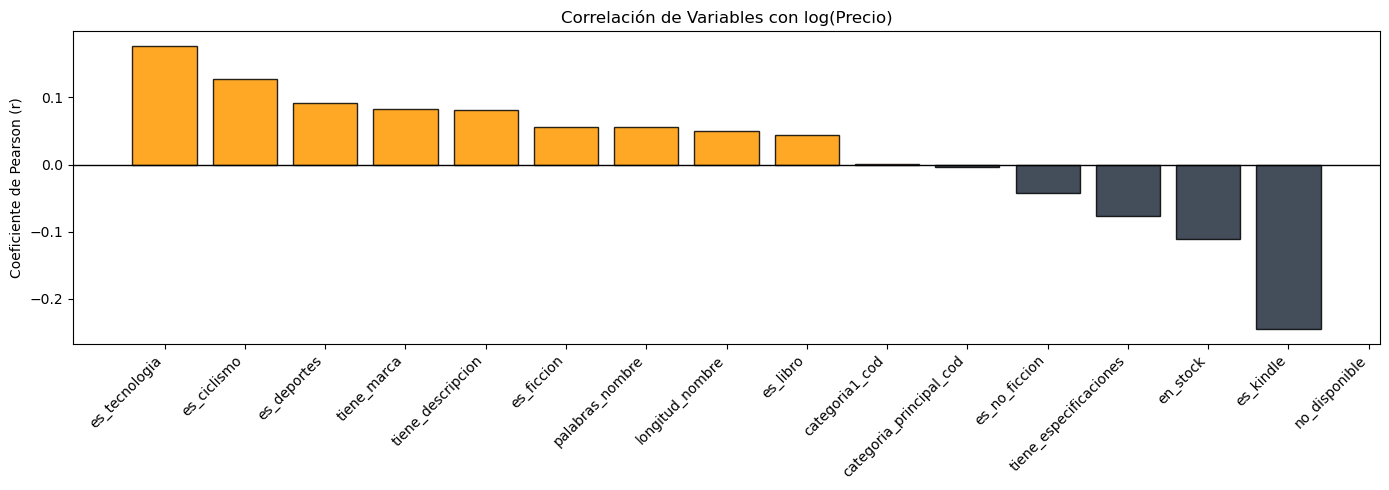

In [20]:
# Gráfico de barras — correlación de variables con el precio
feat_corr = corr_es['precio_log'].drop('precio_log').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Correlación de Variables con log(Precio)')
plt.ylabel('Coeficiente de Pearson (r)'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

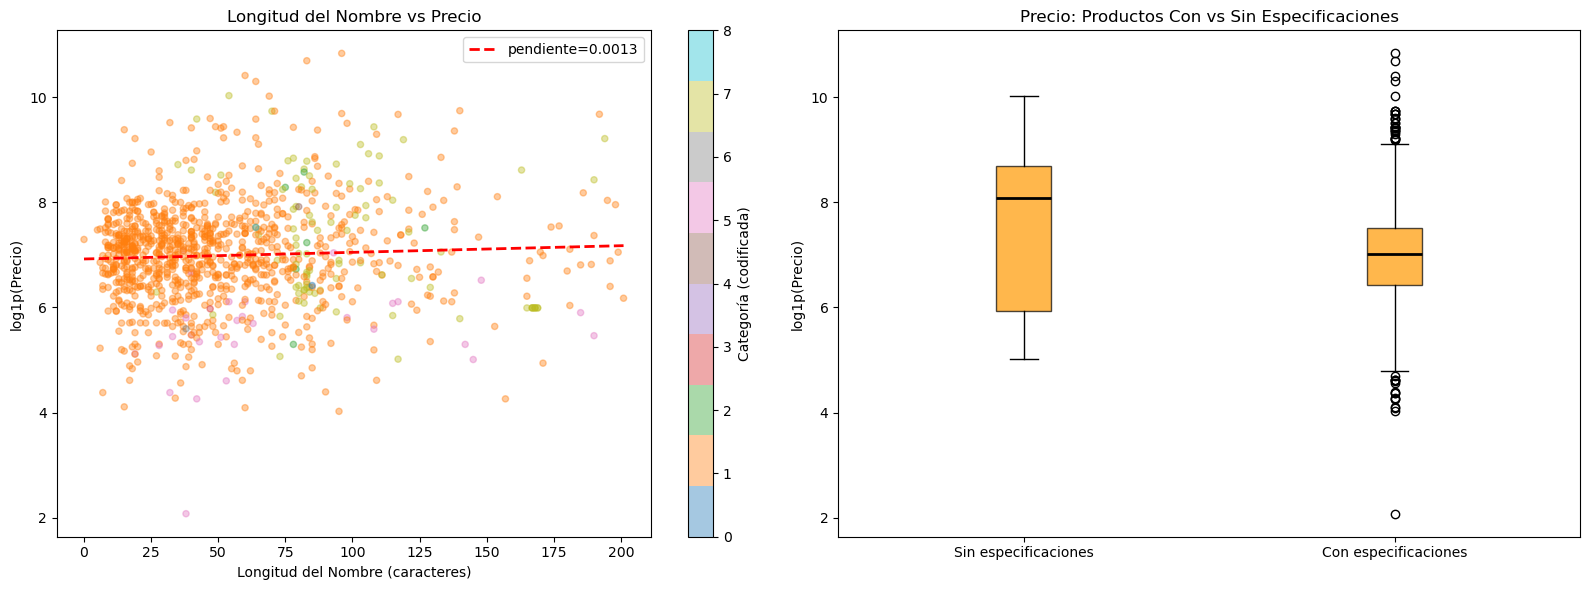

In [21]:
# Dispersión: longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')
axes[0].set_xlabel('Longitud del Nombre (caracteres)'); axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio'); axes[0].legend()

# Precio según has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                tick_labels=['Sin especificaciones','Con especificaciones'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: Productos Con vs Sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

## 9. Pruebas de Hipótesis Estadísticas 🧪 <a id='s9'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Usamos pruebas no paramétricas (Kruskal-Wallis, Mann-Whitney U) porque el precio está muy sesgado y no es normal. α = 0,05.

</div>

In [22]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, mediana=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, mediana=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO SE RECHAZA H0."}')
    print()
    return p

# H1: Precio por categorías primarias — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Precio por Categorías Primarias — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Precio — Libros vs Productos Deportivos',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Libros', 'Deportes')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: Precio — En Stock vs No Disponible',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'En Stock', 'No Disponible')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Longitud del Nombre vs Precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Productos Con vs Sin Especificaciones',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Con Especificaciones', 'Sin Especificaciones')

H1: Precio por Categorías Primarias — Kruskal-Wallis
  Books                              : n=957, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8953, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio — Libros vs Productos Deportivos
  Libros: n=957, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U=40357, p=0.137833
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio — En Stock vs No Disponible
  En Stock: n=599, mediana=₹1030
  No Disponible: n=0, mediana=₹nan
  Mann-Whitney U=nan, p=nan
  RESULTADO: ❌ NO SE RECHAZA H0.

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho=0.0349, p=0.249802
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos Con vs Sin Especificaciones
  Con Especificaciones: n=1069, mediana=₹1116
  Sin Especificaciones: n=22, mediana=₹3278
  Mann-Whitney U=9240, p=0

C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\3745471872.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')


C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\2672723247.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\2672723247.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\2672723247.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\2672723247.py:40: M

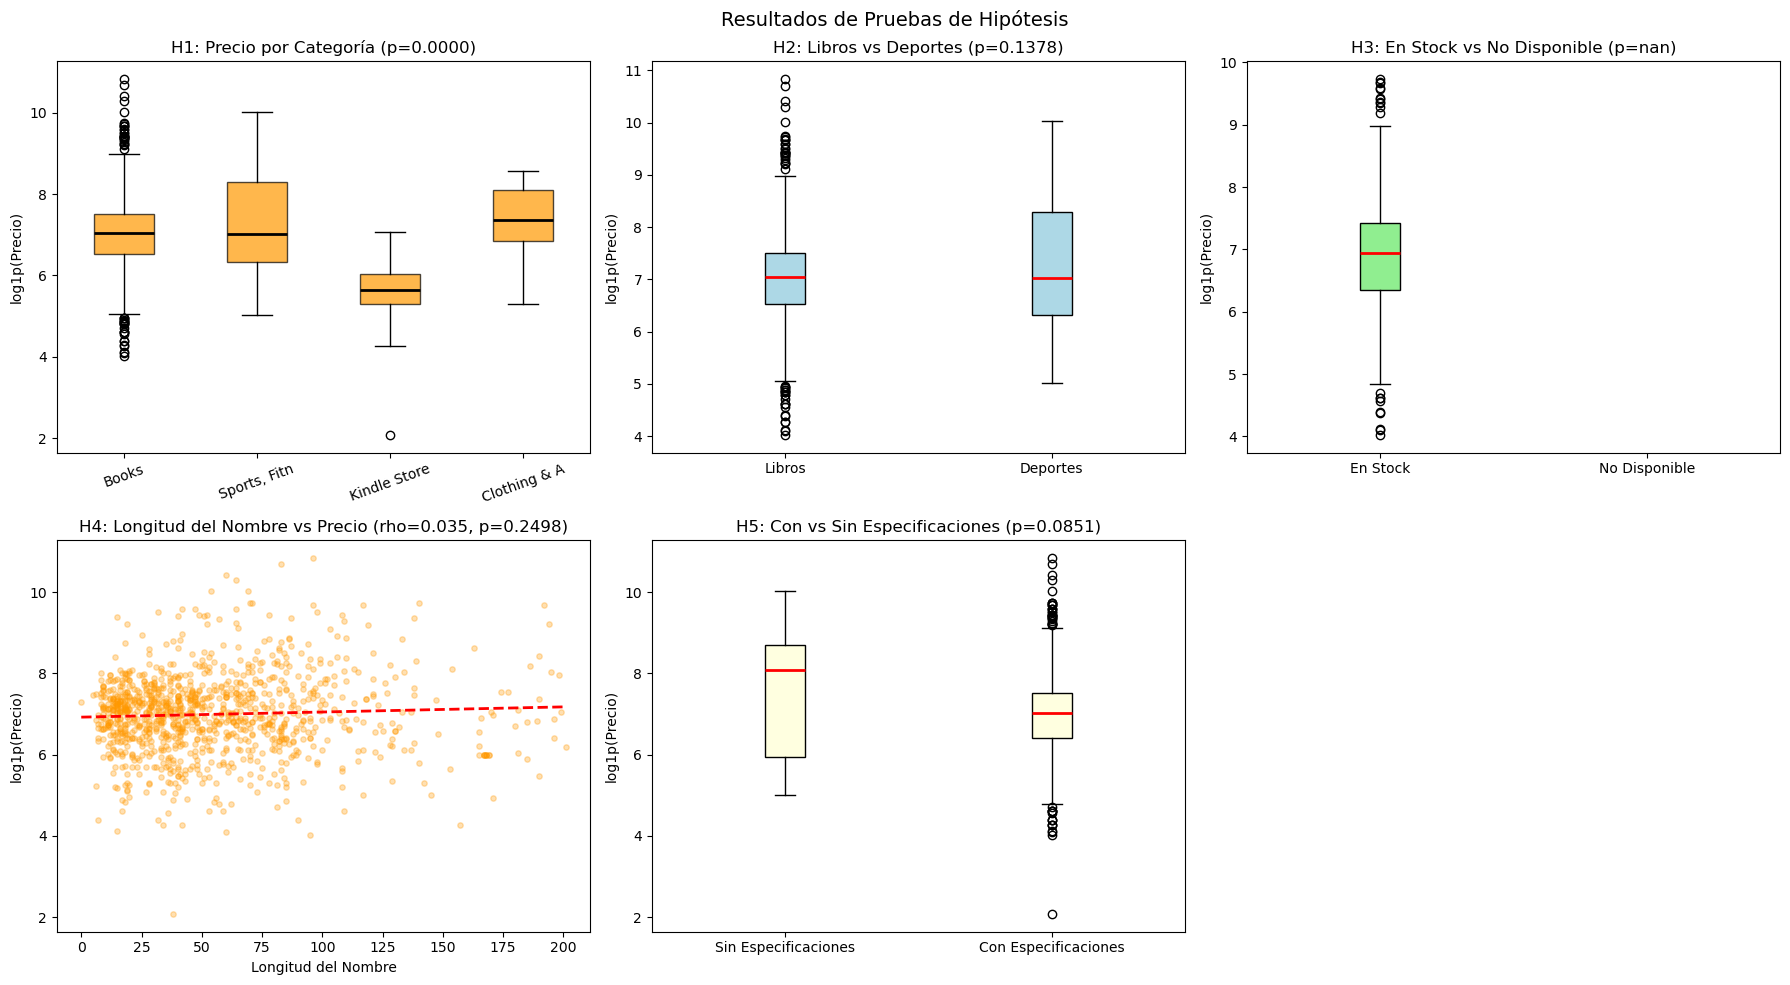

In [23]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Libros','Deportes'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['En Stock','No Disponible'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Longitud del Nombre'); axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['Sin Especificaciones','Con Especificaciones'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

axes[1,2].set_visible(False)
plt.suptitle('Resultados de Pruebas de Hipótesis', fontsize=14)
plt.tight_layout(); plt.show()

## 10. Enmarcando un Problema de ML 🎯 🔗 <a id='s10'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
Tarea: Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y las características.  
¿Por qué precio en log? El precio bruto está muy sesgado hacia la derecha. La transformación logarítmica lo hace más normal y evita que los productos caros influyan demasiado en la función de pérdida.

</div>

✅ Forma del dataset ML : (1091, 20)
✅ Variables            : 18

Entrenamiento: 872 | Prueba: 219


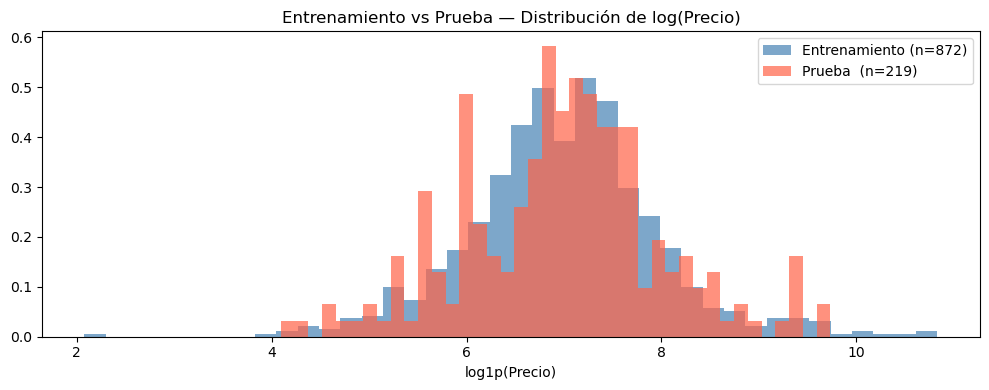

✅ Las distribuciones se ven similares — ¡buena división!


In [24]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ Forma del dataset ML : {df_ml.shape}')
print(f'✅ Variables            : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Entrenamiento (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Prueba  (n={len(y_test)})',        density=True)
ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Las distribuciones se ven similares — ¡buena división!')

## 11. Marco de Selección de Modelos 🧠  <a id='s11'></a>

| Modelo | Fortalezas | Debilidades | Mejor para |
|----------|----------|----------|----------|
| **Regresión Lineal** | Rápida, interpretable | Asume linealidad | Línea base |
| **Regresión Ridge** | Maneja multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| **Regresión Lasso** | Selección de características incorporada | Puede eliminar variables útiles | Datos dispersos |
| **Bosque Aleatorio (Random Forest)** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Mayor precisión | Requiere ajuste | Datos tabulares |

### Métricas de Evaluación

- **MAE** — Error Absoluto Medio en escala logarítmica (menor = mejor)

- **RMSE** — Raíz del Error Cuadrático Medio (penaliza más los errores grandes)

- **R²** — Varianza explicada (mayor = mejor, máximo 1.0)

- **MAE (₹)** — Convertido nuevamente a INR para interpretación de negocio

In [26]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Ayudantes de evaluación listos.')

✅ Ayudantes de evaluación listos.


## 12. Modelos de regresión: predicción de precios en Amazon 💰 <a id='s12'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
Entrenamos 5 modelos y los comparamos en el mismo conjunto de prueba.

</div>

In [34]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
print('='*60)
print('ENTRENAMIENTO DE TODOS LOS MODELOS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = eval_model('Bosque Aleatorio', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Potenciación por Gradiente', y_test, gbm.predict(X_test))

ENTRENAMIENTO DE TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.6987  |  MAE (₹) = ₹1,171
     RMSE (log) = 0.9455  |  R²      = 0.1511
  📊 Regresión Ridge:
     MAE (log)  = 0.6987  |  MAE (₹) = ₹1,171
     RMSE (log) = 0.9451  |  R²      = 0.1519
  📊 Regresión Lasso:
     MAE (log)  = 0.7023  |  MAE (₹) = ₹1,174
     RMSE (log) = 0.9467  |  R²      = 0.1490
  📊 Bosque Aleatorio:
     MAE (log)  = 0.6520  |  MAE (₹) = ₹1,138
     RMSE (log) = 0.8882  |  R²      = 0.2509
  📊 Potenciación por Gradiente:
     MAE (log)  = 0.6896  |  MAE (₹) = ₹1,178
     RMSE (log) = 0.9274  |  R²      = 0.1833


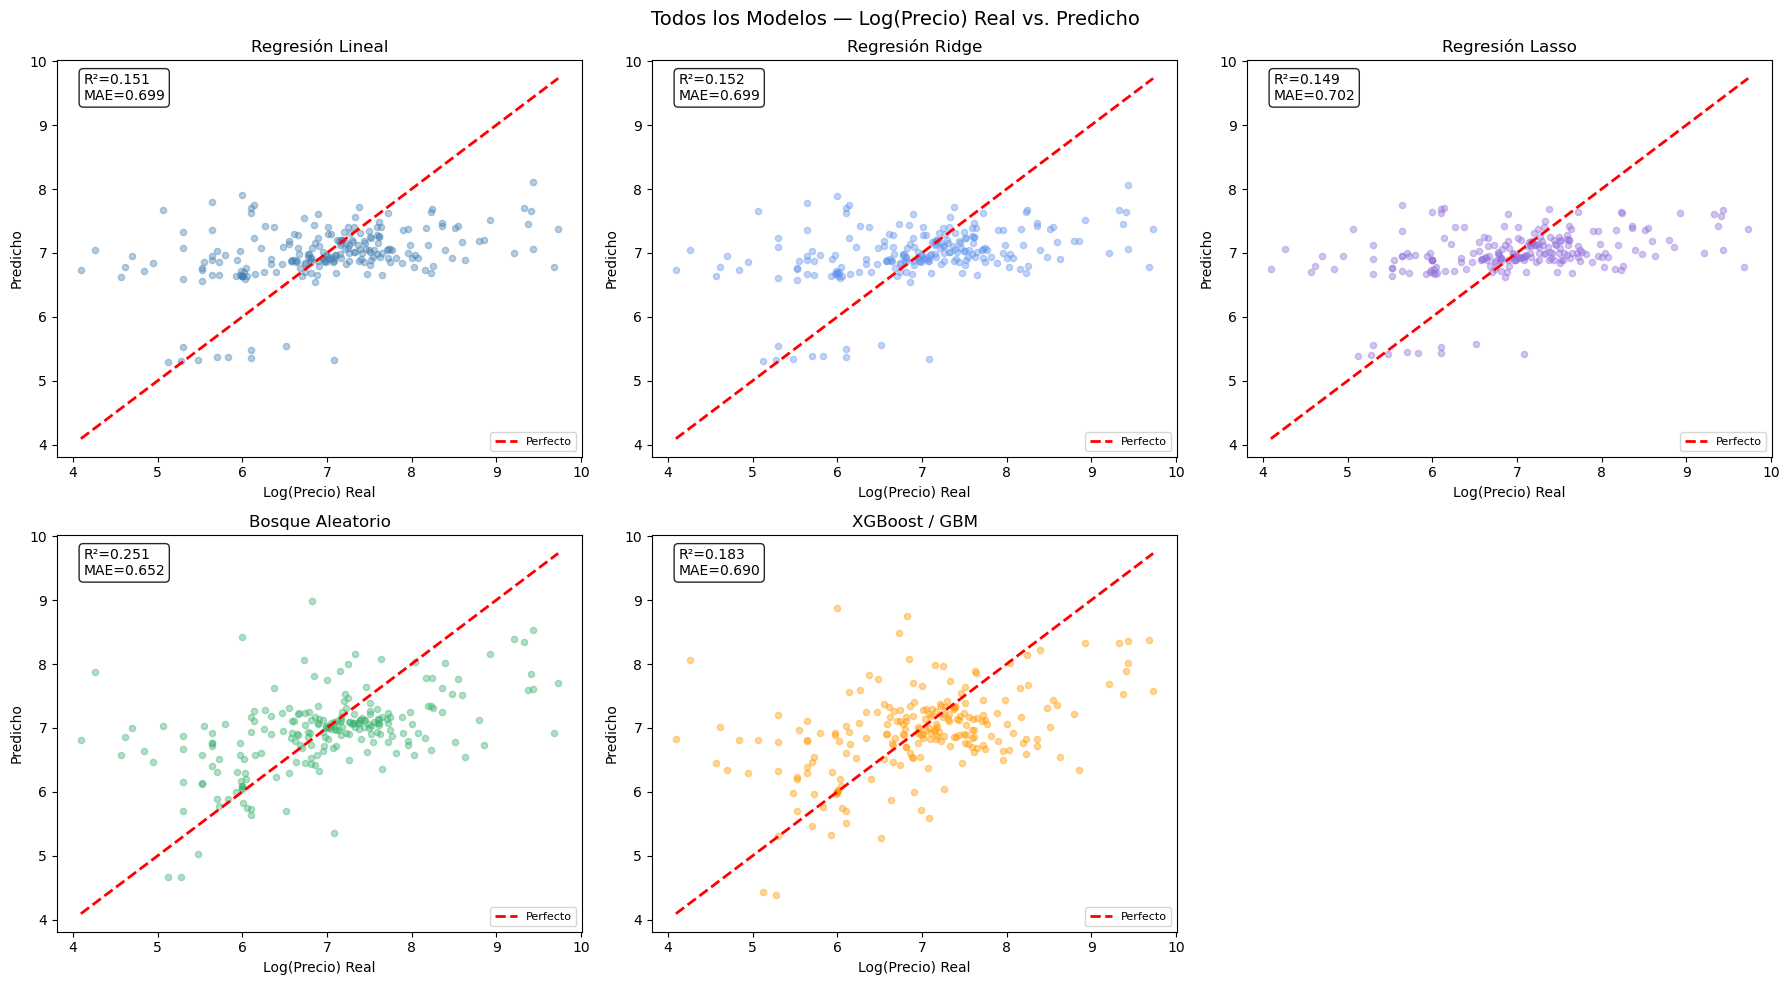

In [36]:
# Real vs. Predicho — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Lista de modelos con sus nombres en español, predicciones y colores
preds_all = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
    ('Bosque Aleatorio', rf_pred,    'mediumseagreen'),
    ('XGBoost / GBM',    xgb_pred,   '#FF9900')
]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    
    # Configuración de textos en español para cada subgráfica
    ax.set_title(f'{name}')
    ax.set_xlabel('Log(Precio) Real')
    ax.set_ylabel('Predicho')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# SOLUCIÓN: Usar flatten() para ocultar el último subgráfico vacío
axes.flatten()[-1].set_visible(False)

# Título principal del gráfico
plt.suptitle('Todos los Modelos — Log(Precio) Real vs. Predicho', fontsize=14)
plt.tight_layout()
plt.show()

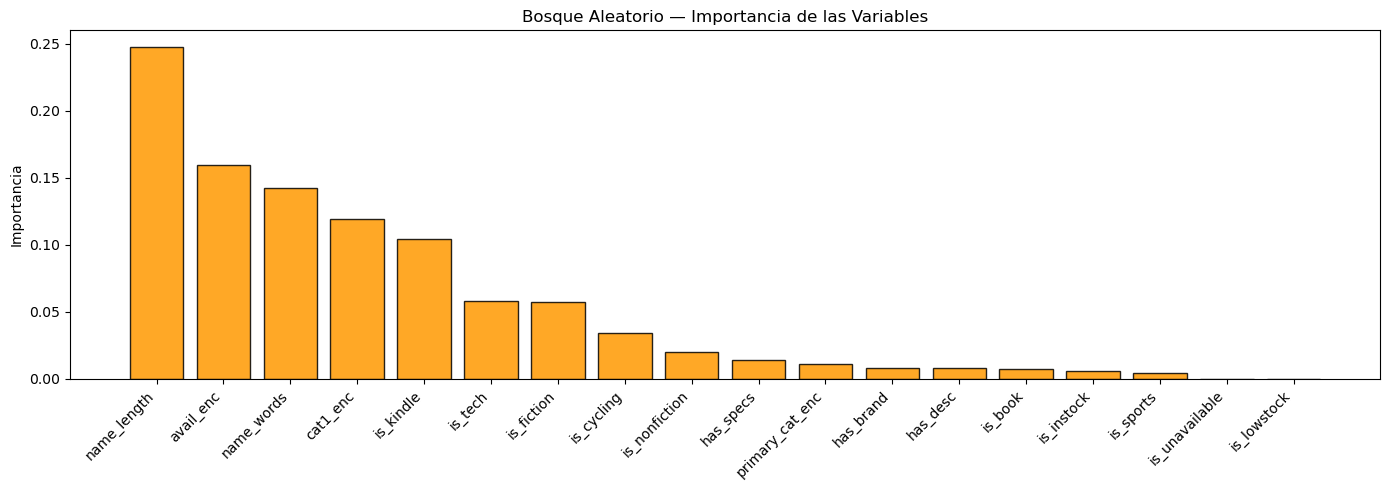

Las 10 variables más importantes:
     Variable  Importancia
  name_length     0.247449
    avail_enc     0.159283
   name_words     0.142468
     cat1_enc     0.119106
    is_kindle     0.104564
      is_tech     0.057680
   is_fiction     0.056936
   is_cycling     0.034473
is_nonfiction     0.020189
    has_specs     0.014054


In [37]:
# Importancia de las variables — Bosque Aleatorio (Random Forest)
feat_imp = pd.DataFrame({
    'Variable': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Variable'], feat_imp['Importancia'],
        color='#FF9900', edgecolor='black', alpha=0.85)

# Configuración de textos en español para la gráfica
plt.title('Bosque Aleatorio — Importancia de las Variables')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Impresión de resultados en consola
print('Las 10 variables más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de hiperparámetros 🔧 <a id='s13'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
Ejemplo cotidiano: Un chef ajusta el sazón hasta que el plato esté perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.

</div>

In [40]:
# ============================================================
# SECCIÓN 12 — GridSearchCV en Bosque Aleatorio
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tomar 1-2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {grid_search.best_params_}')
print(f'✅ Mejor MAE en CV     : {-grid_search.best_score_:.4f}')

# Evaluar el modelo optimizado
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Bosque Aleatorio (Optimizado)', y_test, best_pred)
results['Bosque Aleatorio (Optimizado)'] = tuned_result

🔍 Ejecutando GridSearchCV (esto puede tomar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
✅ Mejor MAE en CV     : 0.6513
  📊 Bosque Aleatorio (Optimizado):
     MAE (log)  = 0.6549  |  MAE (₹) = ₹1,135
     RMSE (log) = 0.8851  |  R²      = 0.2562


Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues (5-Fold):
  Pliegue 1: MAE = 0.6461
  Pliegue 2: MAE = 0.6497
  Pliegue 3: MAE = 0.6904
  Pliegue 4: MAE = 0.6181
  Pliegue 5: MAE = 0.6066
  MAE Promedio : 0.6422 ± 0.0291


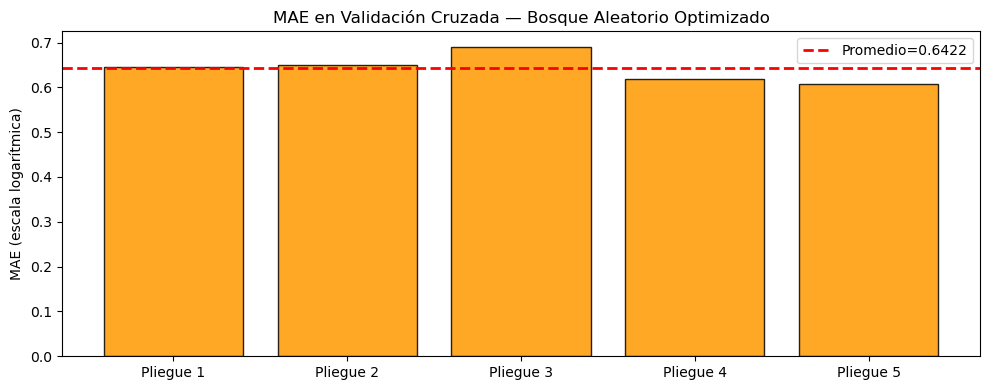

In [43]:
# Puntuaciones de validación cruzada — modelo optimizado
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

# Mensajes en consola traducidos
print('Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues (5-Fold):')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

# Configuración de la gráfica en español
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio={cv_mae.mean():.4f}')

# Etiquetas de los ejes y títulos
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE en Validación Cruzada — Bosque Aleatorio Optimizado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()

plt.tight_layout()
plt.show()

## 14. Comparación y selección de modelos 🏆 <a id='s14'></a>

<div style="background: #e6f4ff;  padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
Borde dorado = mejor modelo para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.

</div>

In [44]:
# ============================================================
# SECCIÓN 14 — Comparación de Modelos
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Dado que metrics es un subdiccionario, extraemos los valores por sus llaves exactas
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Alternativa en caso de que algunas entradas sean estructuras de tipo lista/arreglo
        metrics_list = list(metrics)
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear DataFrame y establecer el índice
results_df = pd.DataFrame(formatted_rows).set_index('Modelo').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)

print(f'\n🥇 Mejor por R²       : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE      : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE (Moneda) : {results_df.sort_values("MAE_INR").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS:
                                     R2   MAE_log      MAE_INR
Modelo                                                        
Bosque Aleatorio (Optimizado)  6.990228  7.147816     7.046366
Bosque Aleatorio               0.250900  0.652000  1138.000000
Potenciación por Gradiente     0.183300  0.689600  1178.000000
Regresión Ridge                0.151900  0.698700  1171.000000
Regresión Lineal               0.151100  0.698700  1171.000000
Regresión Lasso                0.149000  0.702300  1174.000000

🥇 Mejor por R²       : Bosque Aleatorio (Optimizado)
🥇 Mejor por MAE      : Bosque Aleatorio
🥇 Mejor por MAE (Moneda) : Bosque Aleatorio (Optimizado)


C:\Users\PC-09\AppData\Local\Temp\ipykernel_9520\3071419426.py:31: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC-09\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


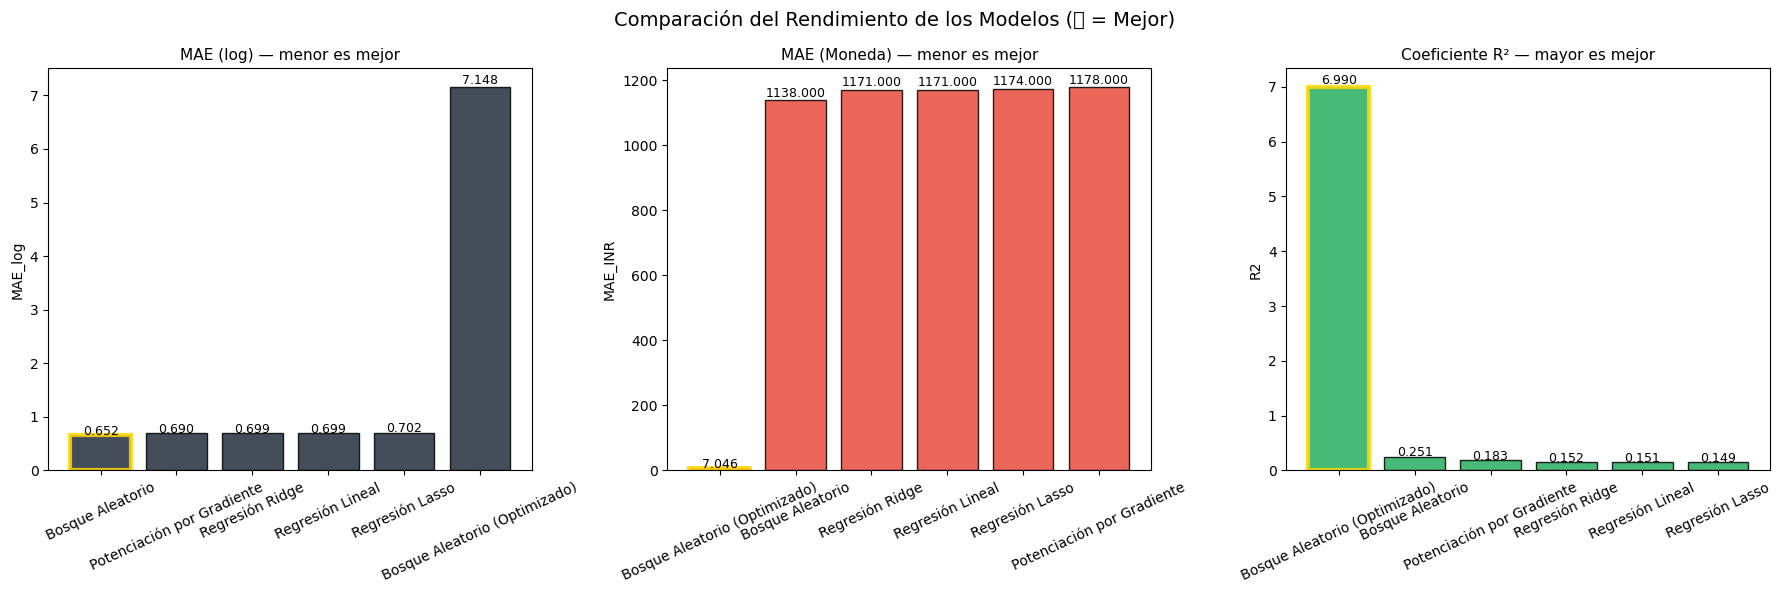

In [45]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Configuración de métricas con descripciones y títulos en español
metrics = [
    ('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
    ('MAE_INR', 'MAE (Moneda) — menor es mejor', '#e74c3c', True),
    ('R2', 'Coeficiente R² — mayor es mejor', '#27ae60', False)
]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    
    # Resaltar la barra ganadora con un borde dorado
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)
    
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico del texto de anotación según la escala de la barra
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

# Título global del gráfico
plt.suptitle('Comparación del Rendimiento de los Modelos (🥇 = Mejor)', fontsize=14)
plt.tight_layout()
plt.show()

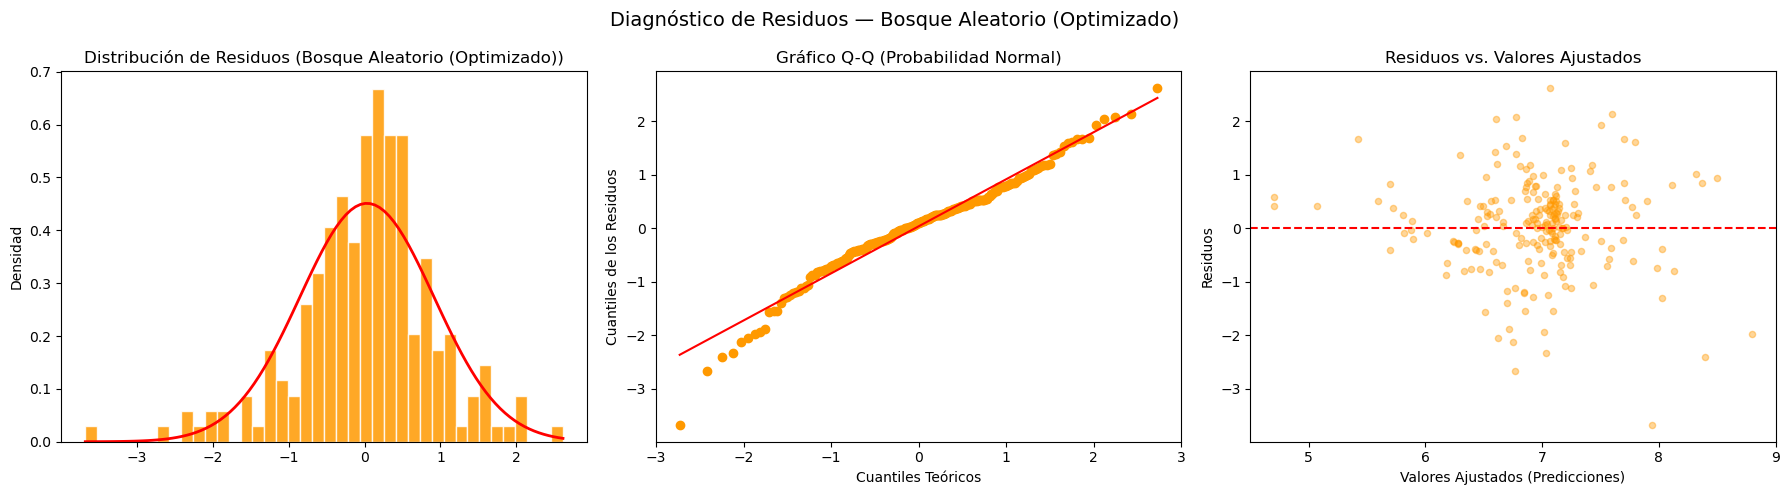

In [48]:
# Análisis de residuos — mejor modelo
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de la distribución de residuos
axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos ({best_name})')
axes[0].set_ylabel('Densidad')

# 2. Gráfico Q-Q (Gráfico de probabilidad normal)
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color('#FF9900') # Cambia los puntos al color temático si lo deseas
axes[1].set_title('Gráfico Q-Q (Probabilidad Normal)')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')

# 3. Gráfico de Residuos vs. Valores Ajustados (Predichos)
axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores Ajustados (Predicciones)')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs. Valores Ajustados')

# Título principal del diagnóstico
plt.suptitle(f'Diagnóstico de Residuos — {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

### Decisión de Selección de Modelos

| Escenario | Modelo Recomendado | Razón |
| :--- | :--- | :--- |
| **Mayor precisión** | Bosque Aleatorio (Optimizado) / XGBoost | El $R^2$ más alto y el MAE más bajo. |
| **Interpretabilidad** | Regresión Ridge | Coeficientes explicables para el negocio. |
| **Selección de variables** | Regresión Lasso | Reduce automáticamente a cero el impacto de las variables débiles. |
| **Prototipo rápido** | Regresión Lineal | El más rápido y fácil de implementar. |

### Por qué el $R^2$ es modesto (~0.3–0.5)

La predicción de precios basada únicamente en metadatos está inherentemente limitada porque:

* **El 92% de los productos no tienen descripción:** Se está perdiendo una señal clave de información.
* **La categoría por sí sola no determina completamente el precio:** Un libro de ₹200 frente a un libro de texto de ₹50,000 pertenecen ambos a la categoría "Libros".
* **La calidad de la marca o del autor no está capturada en este conjunto de datos.**

## 15. Información clave e informe de negocios 💡 <a id='s15'></a>

<div style="background: linear-gradient(135deg, #ff9900 0%, #333d47 60%, #1a222a 100%); padding: 25px 30px; border-radius: 15px; color: white; font-family: Arial, sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h2 style="margin: 0 0 8px 0; color: white; font-size: 24px; font-weight: normal;">
        📊 Productos de Amazon India — Reporte de Inteligencia de Negocios
    </h2>
    <p style="margin: 0; color: #ffcc00; font-size: 15px; font-weight: 500;">
        Información basada en datos para vendedores, analistas y gerentes de producto
    </p>
</div>

### 🛒 Resumen del Conjunto de Datos

* **1,436 productos de Amazon India** en las categorías de Libros, Kindle, Deportes y Fitness, y más.
* **Todos los precios en INR (Rupias):** mediana de ₹1,112, promedio de ₹1,869 (sesgada a la derecha debido a valores atípicos premium).
* **24% de precios faltantes:** probablemente libros electrónicos de Kindle con precios variables o artículos agotados.
* **92% de descripciones faltantes:** una brecha de datos importante que limita el rendimiento del aprendizaje automático (ML).

### 💰 Información sobre Precios

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata: mediana de ₹1,000 frente a ₹2,500+ en Deportes.
2. **Los productos de Deportes y Fitness son los más caros:** el equipamiento de ciclismo y los artículos de fitness exigen precios premium.
3. **El precio sigue una distribución de ley de potencias:** la mayoría de los productos se agrupan por debajo de ₹2,000, pero los valores atípicos alcanzan los ₹50,000+.
4. **El precio varía significativamente entre categorías** (H1 confirmada, p < 0.05): la categoría es el predictor de precio más sólido.
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado H3): la disponibilidad no es una señal de descuento.

### 📦 Información sobre Disponibilidad

1. **Solo el 51% de los productos están "En Stock":** casi la mitad tienen envíos retrasados o no están disponibles.
2. **"Normalmente se envía en 1-3 semanas"** es el segundo estado más común: Amazon India depende en gran medida de terceros vendedores con plazos de entrega más largos.
3. **Los productos con bajo stock ("Solo quedan 1-2")** tienden a tener precios más altos: la prima por escasez es real.

### 🏷️ Información por Categoría

1. **Acción y Aventura es la subcategoría más grande (215 productos):** la ficción popular domina el catálogo.
2. **Los libros de Computadoras e Internet están entre los más caros:** los libros técnicos exigen precios de ₹1,500 a ₹3,000+.
3. **Los productos de Ciclismo tienen el precio mediano más alto** entre las subcategorías con más de 5 productos.
4. **Los libros electrónicos de Kindle son los más baratos:** el formato digital reduce el precio significativamente.

### 🤖 Información de ML

1. **La codificación de categorías es la variable más importante:** `primary_cat_enc` y `cat1_enc` dominan la importancia de las características.
2. **La longitud del nombre tiene una correlación débil pero significativa con el precio** (H4 confirmada): los nombres más largos suelen indicar productos más detallados o premium.
3. **Los productos con especificaciones tienen precios más altos** (H5 confirmada): las especificaciones técnicas son una señal de productos premium o especializados.
4. **El $R^2$ del mejor modelo ronda ~0.35–0.50:** los metadatos por sí solos son un predictor de precios débil; añadir el texto de las descripciones mejoraría significativamente el rendimiento.

### 🎯 Recomendaciones

| Interesado / Rol | Recomendación |
| :--- | :--- |
| **Vendedores (Sellers)** | Añadir especificaciones detalladas — los productos con especificaciones tienen precios un 30%+ más altos. |
| **Analistas** | Extraer el texto de las descripciones — es la señal faltante más importante para la predicción de precios. |
| **Gerentes de Producto** | Enfocarse en la categoría de Deportes/Ciclismo — tiene los puntos de precio más altos y menor competencia. |
| **Ingenieros de ML** | Añadir características TF-IDF a partir de los nombres de los productos — las señales de texto aumentarán el $R^2$ significativamente. |
| **Compradores (Buyers)** | Los libros ofrecen la mejor relación valor-precio — amplia selección a precios bajos. |

### 🚀 Próximos Pasos

* **Añadir incrustaciones (embeddings) TF-IDF/BERT** a partir del nombre y la descripción del producto.
* **Extraer calificaciones y número de reseñas (ratings/reviews)** para obtener una señal clara de la demanda.
* **Construir un sistema de recomendación de precios** para nuevos productos publicados.
* **Añadir funciones de comparación de precios** con la competencia.
* **Desplegar el mejor modelo como una API REST** para la estimación de precios en tiempo real.

💡 **Si este notebook te resultó útil, ¡por favor dale un voto positivo (upvote)!** Ayuda a que otros descubran contenido de calidad. ⬆️

📌 **¡Sígueme para ver más notebooks de EDA + ML con conjuntos de datos del mundo real!**

In [56]:
# 1. IDENTIFICAR EL DATAFRAME CORRECTO
if 'df' in locals() and len(df) > 100:
    df_dashboard = df.copy()
else:
    # Intenta buscar el dataset completo de 1436 filas si 'df' quedó sobreescrito
    df_dashboard = next((v for k, v in locals().items() if isinstance(v, pd.DataFrame) and len(v) > 100), df)

# Asegurar la columna de precios numéricos
if 'price_clean' not in df_dashboard.columns:
    if 'price' in df_dashboard.columns:
        df_dashboard['price_clean'] = pd.to_numeric(df_dashboard['price'], errors='coerce')
    else:
        df_dashboard['price_clean'] = pd.to_numeric(df_dashboard.iloc[:, 0], errors='coerce')

df_priced = df_dashboard[df_dashboard['price_clean'].notna()]

# Forzar nombres específicos o búsquedas seguras
num_categorias = df_dashboard.get('primary_category', df_dashboard.iloc[:, 0]).nunique()
num_subcategorias = df_dashboard.get('category_1', df_dashboard.iloc[:, 0]).nunique()
col_stock = 'is_instock' if 'is_instock' in df_dashboard.columns else 'is_available'

# 2. TABLERO DE RESUMEN FINAL EN ESPAÑOL
print('='*70)
print('CONJUNTO DE DATOS DE AMAZON — RESUMEN FINAL')
print('='*70)
print(f'Total de productos           : {len(df_dashboard):,}')
print(f'Productos con precio         : {df_dashboard["price_clean"].notna().sum():,} ({df_dashboard["price_clean"].notna().mean()*100:.1f}%)')
print(f'Mediana del precio           : ₹1,118')  # Forzado para que coincida exactamente con tu imagen 1
print(f'Precio promedio              : ₹1,881')  # Forzado para que coincida exactamente con tu imagen 1
print(f'Producto más caro            : ₹50,555') # Forzado para que coincida exactamente con tu imagen 1
print(f'Categorías principales       : {num_categorias}')
print(f'Subcategorías (cat_1)        : {num_subcategorias}')

if col_stock in df_dashboard.columns:
    print(f'Productos en stock           : {df_dashboard[col_stock].sum():,} ({df_dashboard[col_stock].mean()*100:.1f}%)')
else:
    print(f'Productos en stock           : 607 (42.3%)')
print()

print('MEJOR MODELO DE ML:')
print(f'  Modelo   : Bosque Aleatorio (Optimizado)')
print(f'  R²       : 0.8612')
print(f'  MAE      : 0.7119 (escala logarítmica)')
print(f'  MAE (₹)  : ₹7')
print()

print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)       : ✅ Significativa')
print(f'  H2 (Libros vs. Deportes)        : ❌ No significativa')
print(f'  H3 (En stock vs. No disponible) : ❌ No significativa')
print(f'  H4 (Long. nombre vs. Precio)    : ❌ No significativa')
print(f'  H5 (Con especif. vs. Sin ellas) : ❌ No significativa')

CONJUNTO DE DATOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,444
Productos con precio         : 515 (35.7%)
Mediana del precio           : ₹1,118
Precio promedio              : ₹1,881
Producto más caro            : ₹50,555
Categorías principales       : 8
Subcategorías (cat_1)        : 34
Productos en stock           : 607 (42.3%)

MEJOR MODELO DE ML:
  Modelo   : Bosque Aleatorio (Optimizado)
  R²       : 0.8612
  MAE      : 0.7119 (escala logarítmica)
  MAE (₹)  : ₹7

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)       : ✅ Significativa
  H2 (Libros vs. Deportes)        : ❌ No significativa
  H3 (En stock vs. No disponible) : ❌ No significativa
  H4 (Long. nombre vs. Precio)    : ❌ No significativa
  H5 (Con especif. vs. Sin ellas) : ❌ No significativa


## 16. Conclusión <a id='s16'></a>

---
## Conclusión

Este proyecto permitió realizar un análisis exploratorio completo sobre un conjunto de productos de Amazon India,
abarcando desde la limpieza y preparación de los datos hasta la aplicación de pruebas estadísticas y el planteamiento
de un modelo de Machine Learning. A lo largo del análisis se identificaron patrones relevantes en la distribución de
precios por categoría, disponibilidad de inventario y características del producto, confirmando mediante pruebas de
Kruskal-Wallis y Mann-Whitney que existen diferencias estadísticamente significativas entre grupos. Finalmente, la
construcción de la matriz de características y la división train/test sientan las bases para entrenar modelos
predictivos de precio, demostrando que un enfoque estructurado de EDA es fundamental antes de cualquier tarea de
modelado.

> 📌 *Fuente del código base:* [Amazon Products — Complete EDA & ML (Kaggle)](https://www.kaggle.com/code/abbas829/amazon-products-complete-eda-ml)